#**Projeto Cronos**
##CHALLENGE LOCAWEB 2026
Integrantes:

* Bruno Rosa - RM563779
* Danilo Alves - RM564109
* Enzo Cremaschi - RM562058
* Vinícius Macedo - RM561911

# EDA Aprofundada — Locaweb Challenge 2026 (Projeto Cronos)
### Análise exploratória de dados completa, por tipo de variável, com foco em subsidiar as decisões da Arquitetura Medalhão (Bronze/Silver/Gold)

**Objetivo deste notebook:** entender profundamente cada coluna do dataset — o que significa, quanto e por que falta, como se distribui, e como se relaciona com as demais — antes de qualquer decisão de modelagem. Este notebook **não modela nada**; ele existe para que toda decisão de engenharia de features feita depois (na camada Silver/Gold) seja justificada por evidência, não por suposição.

**Estrutura:**
1. Carga e visão estrutural geral
2. Dicionário de dados
3. Análise de dados faltantes (*missingness*) — quantidade, padrão, e teste da hipótese de causa
4. Integridade e consistência (duplicatas, datas, *outliers*)
5. Análise univariada por tipo de dado (categóricas, numéricas, datas, texto)
6. Análise temporal (volume, sazonalidade, calendário)
7. Análise bivariada e cruzamentos-chave
8. Análise dedicada da variável-alvo (KPI Violado?)
9. Correlação e associação entre variáveis (Cramér's V para categóricas)
10. Síntese final — o que levar para a Arquitetura Medalhão


## 0. Setup e carga dos dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_excel('/content/drive/MyDrive/LW-DATASET.xlsx')
print(f'Shape bruto: {df.shape[0]:,} linhas x {df.shape[1]} colunas'.replace(',', '.'))
df.head()

Mounted at /content/drive
Shape bruto: 122.543 linhas x 19 colunas


,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
3,INC8654263,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,Problem: Alarm Application Monitoring coupons ...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
4,INC8654262,4 - Baixa,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN


In [ ]:
df_raw = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122543 non-null  object        
 1   Prioridade            122543 non-null  object        
 2   Produto               44608 non-null   object        
 3   Categoria             44822 non-null   object        
 4   Subcategoria          44823 non-null   object        
 5   Grupo designado       122543 non-null  object        
 6   Item de configuração  120763 non-null  object        
 7   Aberto                122543 non-null  datetime64[ns]
 8   Resolvido             40241 non-null   datetime64[ns]
 9   Encerrado             122543 non-null  datetime64[ns]
 10  Duração               122543 non-null  int64         
 11  Código de fechamento  40804 non-null   object        
 12  Descrição resumida    122543 non-null  object        
 13 

## 1. Dicionário de dados

| Coluna | Tipo | Significado | Papel provável no projeto |
|---|---|---|---|
| `Número` | Identificador | Chave única do chamado | Chave primária — nunca feature |
| `Prioridade` | Categórica ordinal | Nível de severidade (1-Crítica a 5-Muito Baixa) | Feature forte em todos os desafios |
| `Produto` | Categórica nominal, alta cardinalidade | Produto/serviço afetado | Feature no Desafio 3; dimensão no Desafio 2 |
| `Categoria` | Categórica nominal, alta cardinalidade | Categoria do incidente | Feature no Desafio 3; dimensão no Desafio 2 |
| `Subcategoria` | Categórica nominal, altíssima cardinalidade | Subcategoria do incidente | Uso provavelmente limitado por esparsidade |
| `Grupo designado` | Categórica nominal, baixa cardinalidade | Equipe/fila responsável pelo atendimento | Feature confiável (sem nulos) em todos os desafios |
| `Item de configuração` | Identificador/categórica | Ativo de infraestrutura associado | Uso exploratório — checar cardinalidade |
| `Aberto` | Data/hora | Timestamp de abertura do chamado | Base de toda a modelagem temporal (Desafio 1) e feature de instante (Desafio 3) |
| `Resolvido` | Data/hora | Timestamp de resolução técnica | Componente de `Duração`; muito nulo — investigar |
| `Encerrado` | Data/hora | Timestamp de encerramento formal | Componente de `Duração` |
| `Duração` | Numérica | Tempo entre abertura e encerramento | Feature candidata — cuidado com vazamento (só existe depois do fechamento) |
| `Código de fechamento` | Categórica | Motivo/código de encerramento | Exploratório — muito nulo |
| `Descrição resumida` | Texto curto | Descrição textual do problema | Feature de texto nativa no CatBoost (Desafio 3); base para clusters (Desafio 2) |
| `Solução` | Texto | Descrição da solução aplicada | Só preenchido em parte dos casos — provável vazamento se usado (só existe após resolução) |
| `Aberto por` | Categórica binária | Origem do chamado (Monitoramento automático vs. Manual) | Variável-chave para entender o padrão de nulos de Produto/Categoria |
| `Incidente Pai` | Identificador | Incidente "guarda-chuva" relacionado | Exploratório — indica agrupamento de chamados correlacionados |
| `Status` | Categórica | Estado atual do chamado | Contexto operacional |
| `Entrou para KPI?` | Categórica binária | Se o chamado está sujeito a acordo de nível de serviço | Filtro de elegibilidade para o Desafio 3 |
| `KPI Violado?` | Categórica binária (com nulo estrutural) | Se houve violação do SLA/OLA | **Variável-alvo do Desafio 3** |

**Atenção a vazamento temporal:** `Resolvido`, `Encerrado`, `Duração`, `Código de fechamento` e `Solução` só existem (ou só fazem sentido) depois que o chamado já foi tratado — nenhuma dessas colunas pode ser usada como feature de um modelo que prevê algo no **instante de abertura** do chamado (que é exatamente o caso do Desafio 3). Elas entram aqui só para fins de EDA e de construção da variável-alvo, nunca como preditor.


## 2. Visão estrutural geral

Shape, tipos de dado e uso de memória — o "raio-x" inicial que orienta o resto da análise.

In [ ]:
print(f"Linhas: {df.shape[0]:,}".replace(',', '.'))
print(f"Colunas: {df.shape[1]}")
print()
print('Tipos de dado por coluna:')
display(df.dtypes.rename('dtype').to_frame())

Linhas: 122.543
Colunas: 19

Tipos de dado por coluna:


,dtype
Número,object
Prioridade,object
Produto,object
Categoria,object
Subcategoria,object
Grupo designado,object
Item de configuração,object
Aberto,datetime64[ns]
Resolvido,datetime64[ns]
Encerrado,datetime64[ns]


In [ ]:
resumo = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_nao_nulos': df.notna().sum(),
    'n_nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2),
    'n_unicos': df.nunique(),
})
resumo = resumo.sort_values('pct_nulos', ascending=False)
resumo

,dtype,n_nao_nulos,n_nulos,pct_nulos,n_unicos
Incidente Pai,object,15127,107416,87.66,3326
Solução,object,15300,107243,87.51,2
KPI Violado?,object,25600,96943,79.11,2
Resolvido,datetime64[ns],40241,82302,67.16,37446
Código de fechamento,object,40804,81739,66.70,17
Produto,object,44608,77935,63.60,51
Categoria,object,44822,77721,63.42,141
Subcategoria,object,44823,77720,63.42,447
Item de configuração,object,120763,1780,1.45,9171
Prioridade,object,122543,0,0.00,5


## 3. Análise de dados faltantes (*missingness*)

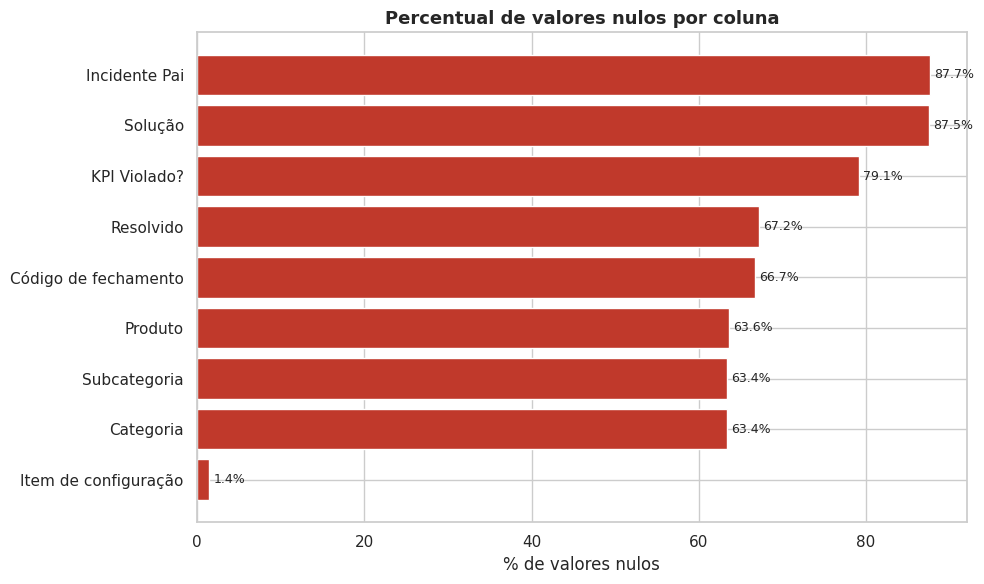

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
resumo_plot = resumo[resumo['pct_nulos'] > 0].sort_values('pct_nulos')
ax.barh(resumo_plot.index, resumo_plot['pct_nulos'], color='#c0392b')
ax.set_xlabel('% de valores nulos')
ax.set_title('Percentual de valores nulos por coluna')
for i, v in enumerate(resumo_plot['pct_nulos']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

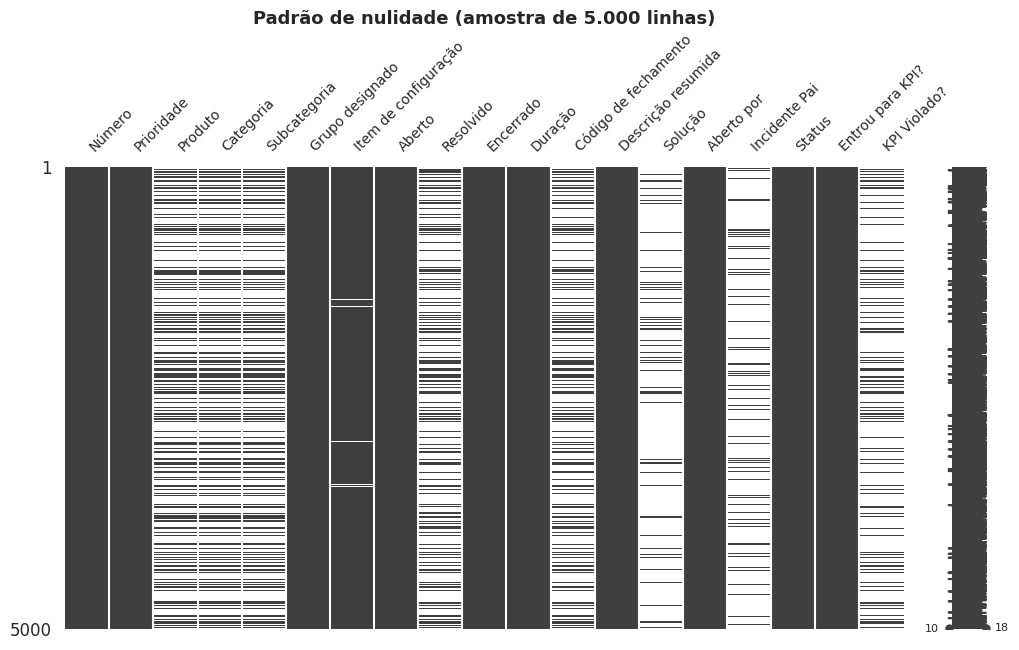

In [ ]:
# Matriz de nulidade (padrão de onde os nulos ocorrem, amostra para performance)
import missingno as msno

amostra = df.sample(min(5000, len(df)), random_state=42)
msno.matrix(amostra, figsize=(12, 6), fontsize=10)
plt.title('Padrão de nulidade (amostra de 5.000 linhas)')
plt.show()


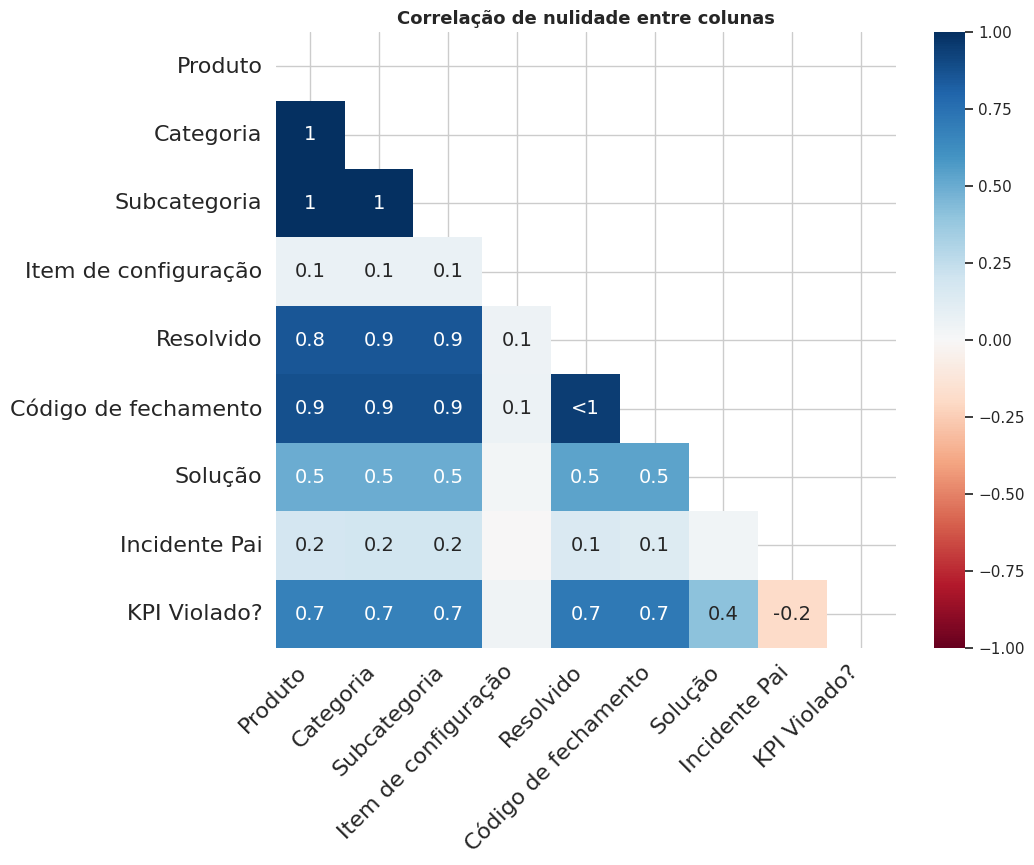

In [ ]:
# Correlação de nulidade entre colunas: colunas que faltam juntas tendem a compartilhar a mesma causa
msno.heatmap(df, figsize=(10, 8))
plt.title("Correlação de nulidade entre colunas")
plt.show()

### 3.1 Testando a hipótese: os nulos de `Produto`/`Categoria`/`Subcategoria` vêm de chamados abertos automaticamente?

A hipótese de trabalho é que chamados de `Aberto por = Monitoramento` (automáticos) não passam por triagem humana e, por isso, nunca recebem categorização — ou seja, o nulo não é "dado perdido", é "dado que nunca existiu" (missing not at random). Vamos testar diretamente.

In [ ]:
crosstab_origem_nulo = pd.crosstab(
    df['Aberto por'],
    df['Produto'].isna().map({True: 'Produto nulo', False: 'Produto preenchido'}),
    margins=True
)
crosstab_origem_nulo

Produto,Produto nulo,Produto preenchido,All
Aberto por,,,
Manual,112,18132,18244
Monitoramento,77823,26476,104299
All,77935,44608,122543


In [ ]:
crosstab_pct = pd.crosstab(df['Aberto por'], df['Produto'].isna(), normalize='index') * 100
crosstab_pct.columns = ['Produto preenchido (%)', 'Produto nulo (%)']
crosstab_pct.round(1)

,Produto preenchido (%),Produto nulo (%)
Aberto por,,
Manual,99.4,0.6
Monitoramento,25.4,74.6


In [ ]:
# Teste qui-quadrado: a nulidade de Produto é estatisticamente dependente de Aberto por?
tabela = pd.crosstab(df['Aberto por'], df['Produto'].isna())
chi2, p_valor, dof, esperado = chi2_contingency(tabela)
print(f'Qui-quadrado: {chi2:.2f}')
print(f'p-valor: {p_valor:.2e}')
print('Conclusão:', 'nulidade DEPENDE fortemente de Aberto por' if p_valor < 0.05 else 'sem dependência estatística significativa')

Qui-quadrado: 36726.99
p-valor: 0.00e+00
Conclusão: nulidade DEPENDE fortemente de Aberto por


**Interpretação esperada:** se o p-valor for muito baixo (praticamente certo, dado o tamanho da base), confirma que a ausência de categorização está estruturalmente ligada à origem automática do chamado. Isso tem uma implicação direta de modelagem: **não faz sentido tentar "recuperar" essas categorias por imputação preditiva** — o valor nunca existiu para ser recuperado. A decisão correta é tratar o nulo como sua própria categoria informativa (`"Não categorizado"` ou deixar como nulo nativo para modelos como CatBoost, que tratam isso automaticamente).

### 3.2 Outras colunas com nulos relevantes — mesma lógica de investigação

`Solução`, `Código de fechamento`, `Incidente Pai` e `Resolvido` também têm muitos nulos. Aqui a causa provável é diferente: são campos que só existem **depois** de o chamado ser tratado/resolvido — logo, nulo aqui pode simplesmente significar "ainda não chegou nessa etapa do fluxo" (ligado a `Status`), não um problema de qualidade de dado.

In [ ]:
for col in ['Solução', 'Código de fechamento', 'Incidente Pai', 'Resolvido']:
    print(f'--- {col} nulo, por Status ---')
    display(pd.crosstab(df['Status'], df[col].isna(), normalize='index').round(3) * 100)
    print()

--- Solução nulo, por Status ---


Solução,False,True
Status,,
Aguardando Problema,0.0,100.0
Encerrado,33.1,66.9
Encerrado Automaticamente,38.1,61.9
Sem Intervenção,0.0,100.0



--- Código de fechamento nulo, por Status ---


Código de fechamento,False,True
Status,,
Aguardando Problema,0.0,100.0
Encerrado,94.0,6.0
Encerrado Automaticamente,98.3,1.7
Sem Intervenção,0.0,100.0



--- Incidente Pai nulo, por Status ---


Incidente Pai,False,True
Status,,
Aguardando Problema,0.0,100.0
Encerrado,29.1,70.9
Encerrado Automaticamente,15.3,84.7
Sem Intervenção,8.2,91.8



--- Resolvido nulo, por Status ---


Resolvido,False,True
Status,,
Aguardando Problema,0.0,100.0
Encerrado,97.5,2.5
Encerrado Automaticamente,94.3,5.7
Sem Intervenção,0.0,100.0


## 4. Integridade e consistência dos dados

Verificações de qualidade que precisam acontecer antes de qualquer modelagem — inconsistências aqui, se não tratadas, se propagam silenciosamente para todos os desafios.

In [ ]:
print('Duplicatas de linha inteira:', df.duplicated().sum())
print('Duplicatas de Número (chave):', df['Número'].duplicated().sum())

Duplicatas de linha inteira: 0
Duplicatas de Número (chave): 0


In [ ]:
# Consistência temporal: Encerrado deveria ser sempre >= Aberto
inconsistentes = df[df['Encerrado'] < df['Aberto']]
print(f'Chamados com Encerrado < Aberto: {len(inconsistentes)} ({len(inconsistentes)/len(df)*100:.3f}%)')
inconsistentes[['Número', 'Aberto', 'Encerrado', 'Resolvido']].head(10)

Chamados com Encerrado < Aberto: 0 (0.000%)


,Número,Aberto,Encerrado,Resolvido


In [ ]:
# Resolvido deveria estar entre Aberto e Encerrado, quando existir
mask_resolvido = df['Resolvido'].notna()
resolvido_antes_aberto = df[mask_resolvido & (df['Resolvido'] < df['Aberto'])]
resolvido_depois_encerrado = df[mask_resolvido & (df['Resolvido'] > df['Encerrado'])]
print(f'Resolvido antes de Aberto: {len(resolvido_antes_aberto)}')
print(f'Resolvido depois de Encerrado: {len(resolvido_depois_encerrado)}')

Resolvido antes de Aberto: 0
Resolvido depois de Encerrado: 32


In [ ]:
# Duração: valores negativos, zero, ou implausivelmente altos
print(df['Duração'].describe())
print()
print('Duração negativa:', (df['Duração'] < 0).sum())
print('Duração igual a zero:', (df['Duração'] == 0).sum())

# Checagem cruzada: Duração bate com (Encerrado - Aberto) em minutos/segundos?
delta_calculado = (df['Encerrado'] - df['Aberto'])
print()
print('Amostra do delta calculado (Encerrado - Aberto) vs. coluna Duração:')
display(pd.DataFrame({
    'Duração_coluna': df['Duração'].head(5),
    'delta_segundos': delta_calculado.dt.total_seconds().head(5),
    'delta_minutos': (delta_calculado.dt.total_seconds() / 60).head(5),
}))


count    1.225430e+05
mean     2.485470e+05
std      2.480123e+06
min      1.000000e+00
25%      2.630000e+02
50%      9.780000e+02
75%      4.240500e+03
max      8.828048e+07
Name: Duração, dtype: float64

Duração negativa: 0
Duração igual a zero: 0

Amostra do delta calculado (Encerrado - Aberto) vs. coluna Duração:


,Duração_coluna,delta_segundos,delta_minutos
0,14,14.0,0.233333
1,209,209.0,3.483333
2,110,110.0,1.833333
3,110,110.0,1.833333
4,42,42.0,0.700000


## 5. Análise univariada por tipo de dado

### 5.1 Variáveis categóricas — cardinalidade e concentração


In [ ]:
categoricas = ['Prioridade', 'Produto', 'Categoria', 'Subcategoria', 'Grupo designado',
               'Item de configuração', 'Código de fechamento', 'Aberto por',
               'Status', 'Entrou para KPI?', 'KPI Violado?']

cardinalidade = df[categoricas].nunique().sort_values(ascending=False)
cardinalidade.rename('n_categorias_unicas').to_frame()


,n_categorias_unicas
Item de configuração,9171
Subcategoria,447
Categoria,141
Produto,51
Grupo designado,17
Código de fechamento,17
Prioridade,5
Status,4
Aberto por,2
Entrou para KPI?,2


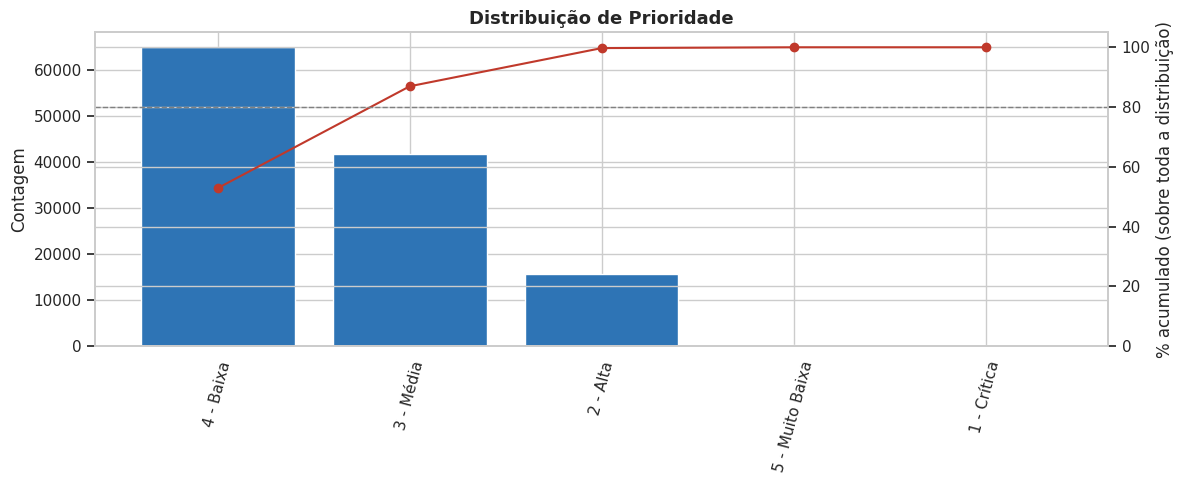

As top-15 categorias cobrem 100.0% dos casos não nulos.


In [ ]:
def plot_pareto(serie, titulo, top_n=15):
    contagem = serie.value_counts().head(top_n)
    pct_acumulado = (serie.value_counts(normalize=True).cumsum() * 100)

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.bar(contagem.index.astype(str), contagem.values, color='#2E74B5')
    ax1.set_ylabel('Contagem')
    ax1.tick_params(axis='x', rotation=75)
    ax1.set_title(titulo)

    ax2 = ax1.twinx()
    ax2.plot(range(len(contagem)), pct_acumulado.head(top_n).values, color='#c0392b', marker='o')
    ax2.set_ylabel('% acumulado (sobre toda a distribuição)')
    ax2.set_ylim(0, 105)
    ax2.axhline(80, color='grey', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()

    cobertura_top_n = serie.value_counts(normalize=True).head(top_n).sum() * 100
    print(f'As top-{top_n} categorias cobrem {cobertura_top_n:.1f}% dos casos não nulos.')

plot_pareto(df['Prioridade'], 'Distribuição de Prioridade')


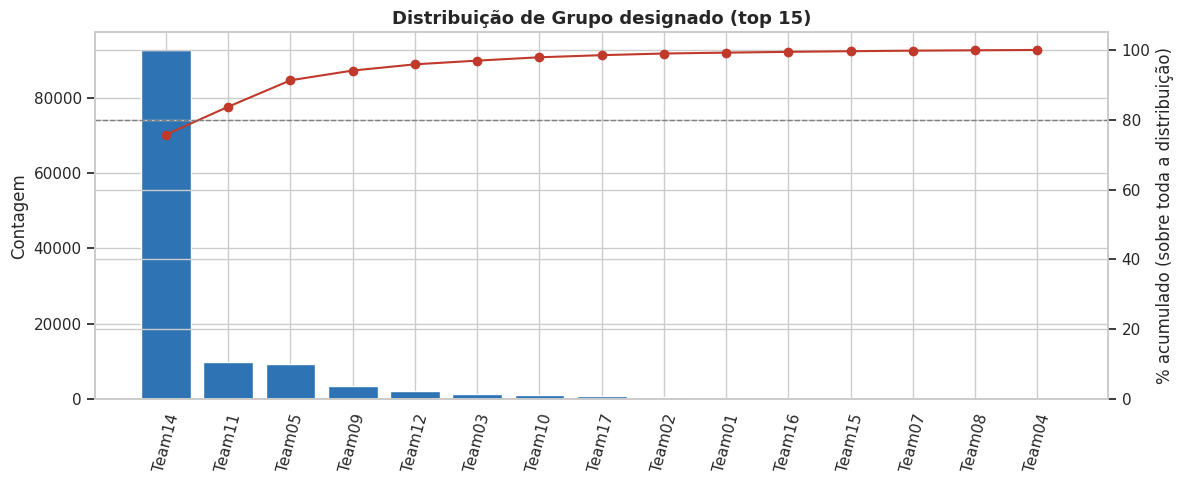

As top-15 categorias cobrem 100.0% dos casos não nulos.


In [ ]:
plot_pareto(df['Grupo designado'], 'Distribuição de Grupo designado (top 15)')

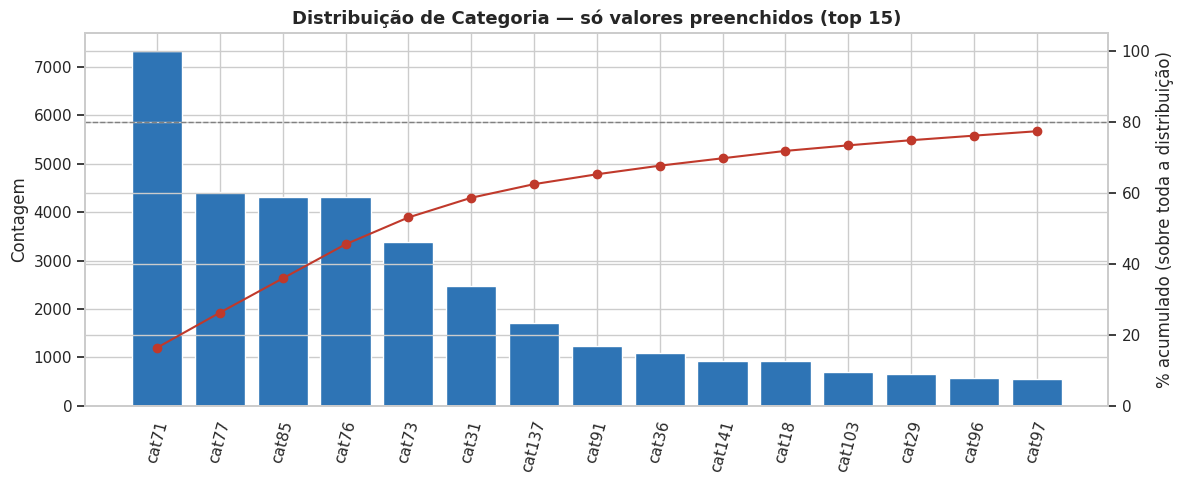

As top-15 categorias cobrem 77.3% dos casos não nulos.


In [ ]:
plot_pareto(df['Categoria'].dropna(), 'Distribuição de Categoria — só valores preenchidos (top 15)')

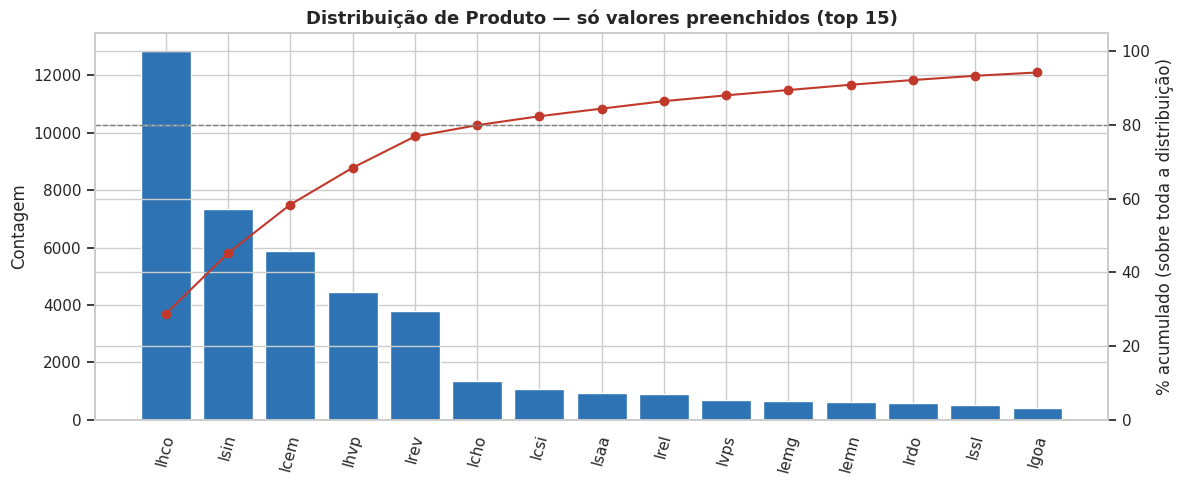

As top-15 categorias cobrem 94.3% dos casos não nulos.


In [ ]:
plot_pareto(df['Produto'].dropna(), 'Distribuição de Produto — só valores preenchidos (top 15)')

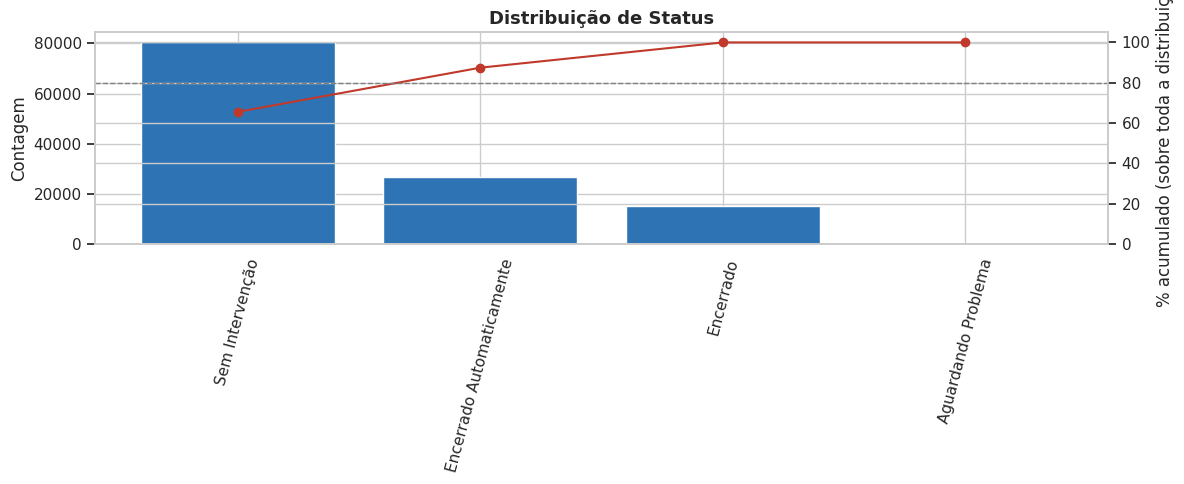

As top-15 categorias cobrem 100.0% dos casos não nulos.


In [ ]:
plot_pareto(df['Status'], 'Distribuição de Status')

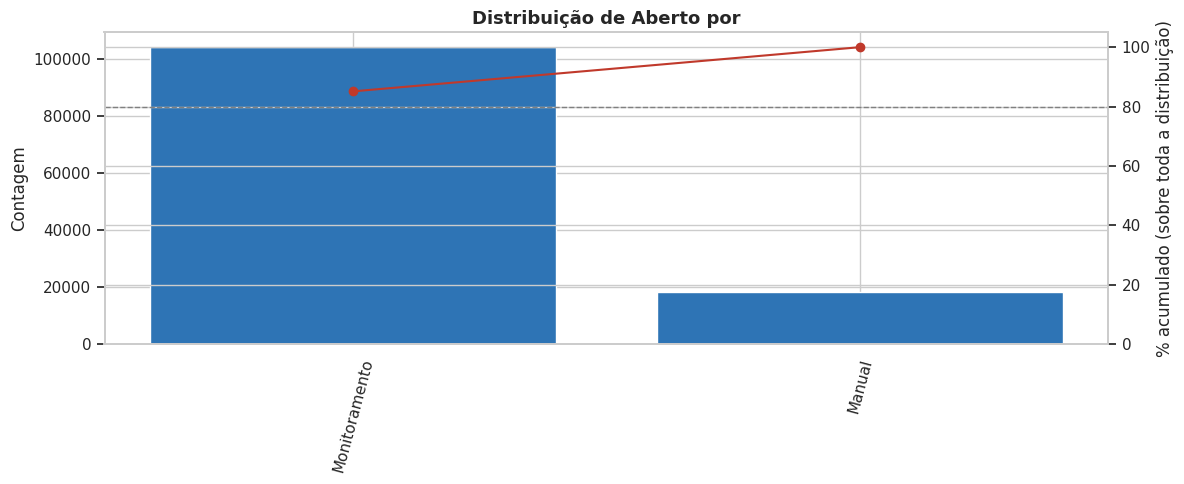

As top-15 categorias cobrem 100.0% dos casos não nulos.


In [ ]:
plot_pareto(df['Aberto por'], 'Distribuição de Aberto por')

In [ ]:
for col in ['Entrou para KPI?', 'KPI Violado?']:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print(df[col].value_counts(normalize=True, dropna=False).round(4) * 100)
    print()

--- Entrou para KPI? ---
Entrou para KPI?
NAO    96943
SIM    25600
Name: count, dtype: int64
Entrou para KPI?
NAO    79.11
SIM    20.89
Name: proportion, dtype: float64

--- KPI Violado? ---
KPI Violado?
NaN    96943
NAO    25352
SIM      248
Name: count, dtype: int64
KPI Violado?
NaN    79.11
NAO    20.69
SIM     0.20
Name: proportion, dtype: float64



### 5.2 Variável numérica — `Duração`

Tempo de atendimento costuma ter distribuição de cauda longa (poucos chamados demoram muito, a maioria é resolvida rápido) — vale checar e decidir se uma transformação logarítmica é necessária antes de usar em qualquer modelo ou visualização.

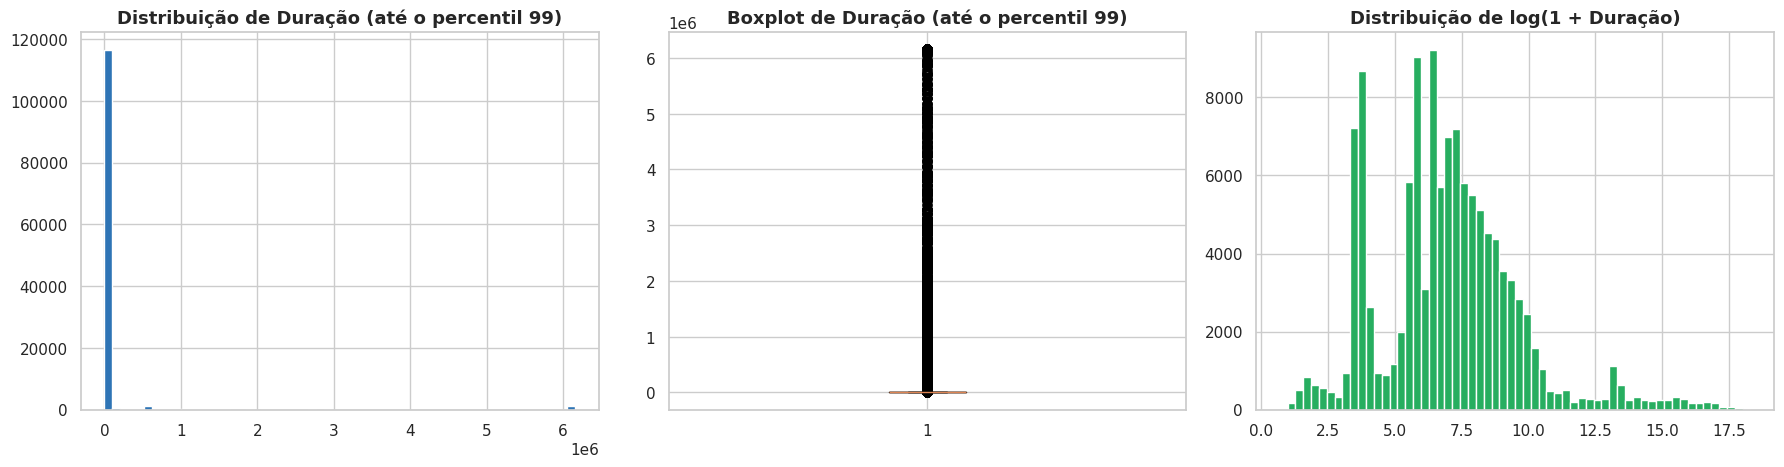

count    1.225430e+05
mean     2.485470e+05
std      2.480123e+06
min      1.000000e+00
25%      2.630000e+02
50%      9.780000e+02
75%      4.240500e+03
max      8.828048e+07
Name: Duração, dtype: float64

Percentis relevantes:
  p50: 978.0
  p75: 4.240.5
  p90: 18.434.8
  p95: 101.052.2
  p99: 6.157.756.9


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['Duração'].clip(upper=df['Duração'].quantile(0.99)), bins=60, color='#2E74B5')
axes[0].set_title('Distribuição de Duração (até o percentil 99)')

axes[1].boxplot(df['Duração'].clip(upper=df['Duração'].quantile(0.99)), vert=True)
axes[1].set_title('Boxplot de Duração (até o percentil 99)')

log_duracao = np.log1p(df['Duração'].clip(lower=0))
axes[2].hist(log_duracao, bins=60, color='#27ae60')
axes[2].set_title('Distribuição de log(1 + Duração)')

plt.tight_layout()
plt.show()

print(df['Duração'].describe())
print()
print('Percentis relevantes:')
for q in [0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f'  p{int(q*100)}: {df["Duração"].quantile(q):,.1f}'.replace(',', '.'))

### 5.3 Variáveis de data/hora

Granularidade, intervalo coberto e distribuição por hora/dia da semana — insumo direto para o Desafio 1 e para a feature de "instante do dia" no Desafio 3.

In [ ]:
for col in ['Aberto', 'Resolvido', 'Encerrado']:
    s = df[col].dropna()
    print(f'{col}: de {s.min()} até {s.max()} | {s.dt.date.nunique()} dias distintos com registro')


Aberto: de 2023-01-02 20:19:58 até 2025-12-31 23:45:18 | 644 dias distintos com registro
Resolvido: de 2024-12-27 00:50:52 até 2025-12-31 19:36:58 | 370 dias distintos com registro
Encerrado: de 2025-01-01 00:10:45 até 2025-12-31 23:45:32 | 365 dias distintos com registro


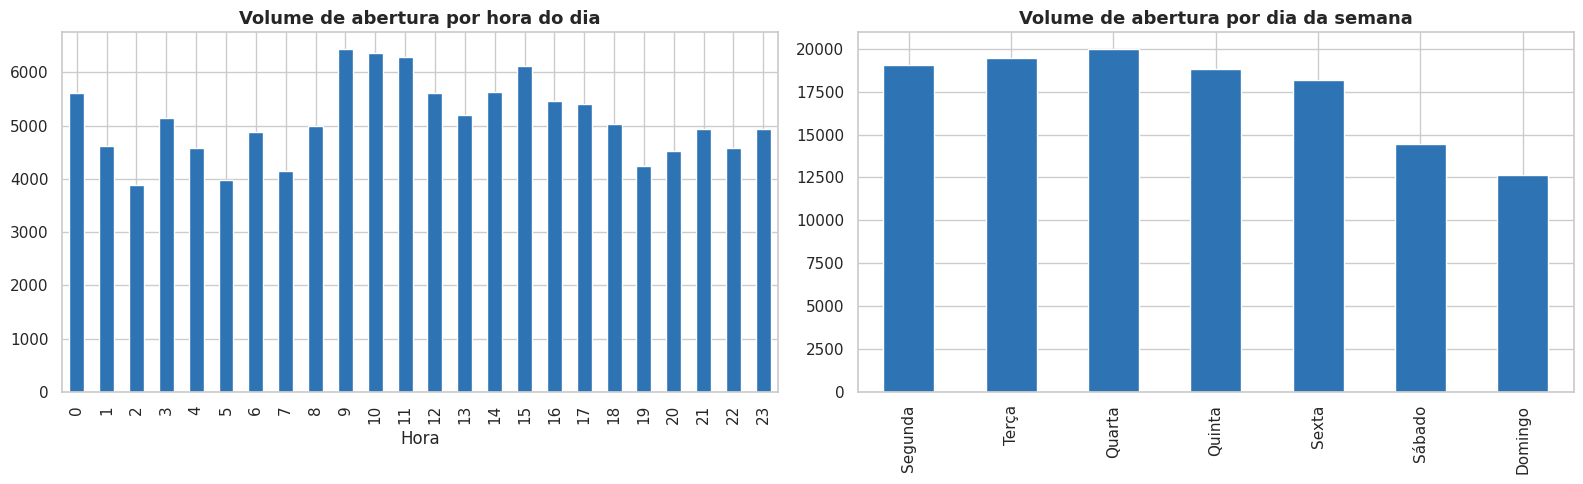

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['Aberto'].dt.hour.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#2E74B5')
axes[0].set_title('Volume de abertura por hora do dia')
axes[0].set_xlabel('Hora')

dias_semana_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
contagem_dow = df['Aberto'].dt.dayofweek.value_counts().sort_index()
contagem_dow.index = dias_semana_pt
contagem_dow.plot(kind='bar', ax=axes[1], color='#2E74B5')
axes[1].set_title('Volume de abertura por dia da semana')

plt.tight_layout()
plt.show()

### 5.4 Texto — `Descrição resumida`

Antes de decidir a estratégia de NLP (TF-IDF+K-Means, ou `text_features` nativo do CatBoost), vale entender o quão repetitivo/templatizado o texto é — isso muda completamente a abordagem ideal.

In [ ]:
n_total = len(df)
n_unicos = df['Descrição resumida'].nunique()
print(f'Textos únicos: {n_unicos:,} em {n_total:,} linhas ({n_unicos/n_total*100:.1f}% de unicidade)'.replace(',', '.'))
print()
print('Top 15 descrições mais frequentes (evidência de templates automáticos):')
df['Descrição resumida'].value_counts().head(15)

Textos únicos: 18.021 em 122.543 linhas (14.7% de unicidade)

Top 15 descrições mais frequentes (evidência de templates automáticos):


,count
Descrição resumida,
Problem: Check Application Monitoring,28728
Problem: Free disk space is less than 10% on volume /,4770
Problem: Check Application Monitoring VIP,4281
Problem: Unavailable by ICMP ping,4133
Problem: Apache Busy Workers,3925
Problem: Lack of free swap space 40m <5%,3255
Problem: Processor load is too high P3,2174
Problem: High bandwidth >60% at least 15m,1874
Problem: Error Backup Full Bacula,1689


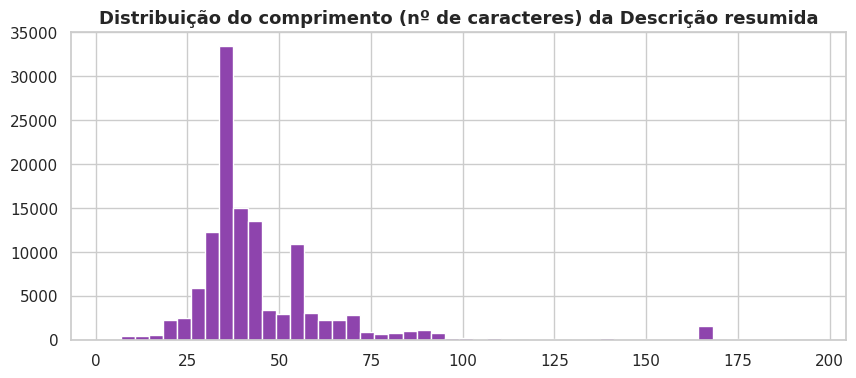

count    122543.000000
mean         45.745885
std          22.489524
min           3.000000
25%          37.000000
50%          39.000000
75%          52.000000
max         195.000000
Name: Descrição resumida, dtype: float64


In [ ]:
comprimento = df['Descrição resumida'].str.len()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(comprimento, bins=50, color='#8e44ad')
ax.set_title('Distribuição do comprimento (nº de caracteres) da Descrição resumida')
plt.show()
print(comprimento.describe())

## 6. Análise temporal — volume, sazonalidade e calendário

Esta seção é o insumo direto para o Desafio 1 (SARIMAX). O objetivo é visualizar a série antes de qualquer modelagem, para confirmar (ou refutar) as hipóteses já levantadas sobre mudança de regime entre 2023-2024 e 2025.

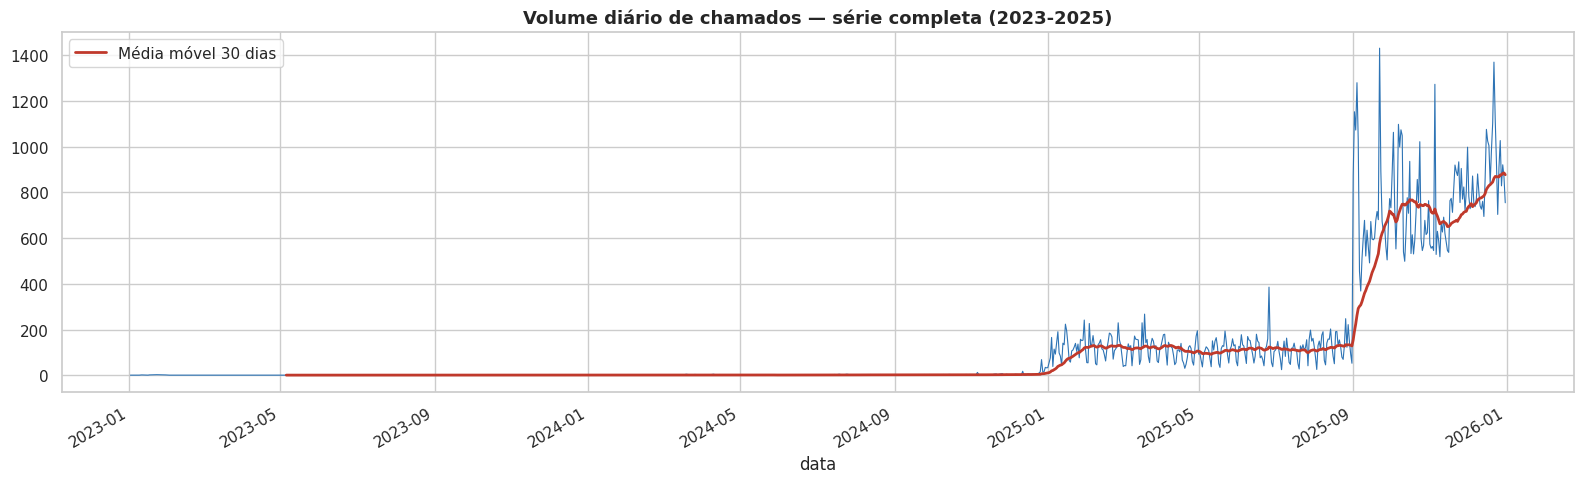

In [ ]:
df['data'] = df['Aberto'].dt.date
volume_diario = df.groupby('data').size()
volume_diario.index = pd.to_datetime(volume_diario.index)

fig, ax = plt.subplots(figsize=(16, 5))
volume_diario.plot(ax=ax, color='#2E74B5', linewidth=0.8)
volume_diario.rolling(30).mean().plot(ax=ax, color='#c0392b', linewidth=2, label='Média móvel 30 dias')
ax.set_title('Volume diário de chamados — série completa (2023-2025)')
ax.legend()
plt.tight_layout()
plt.show()

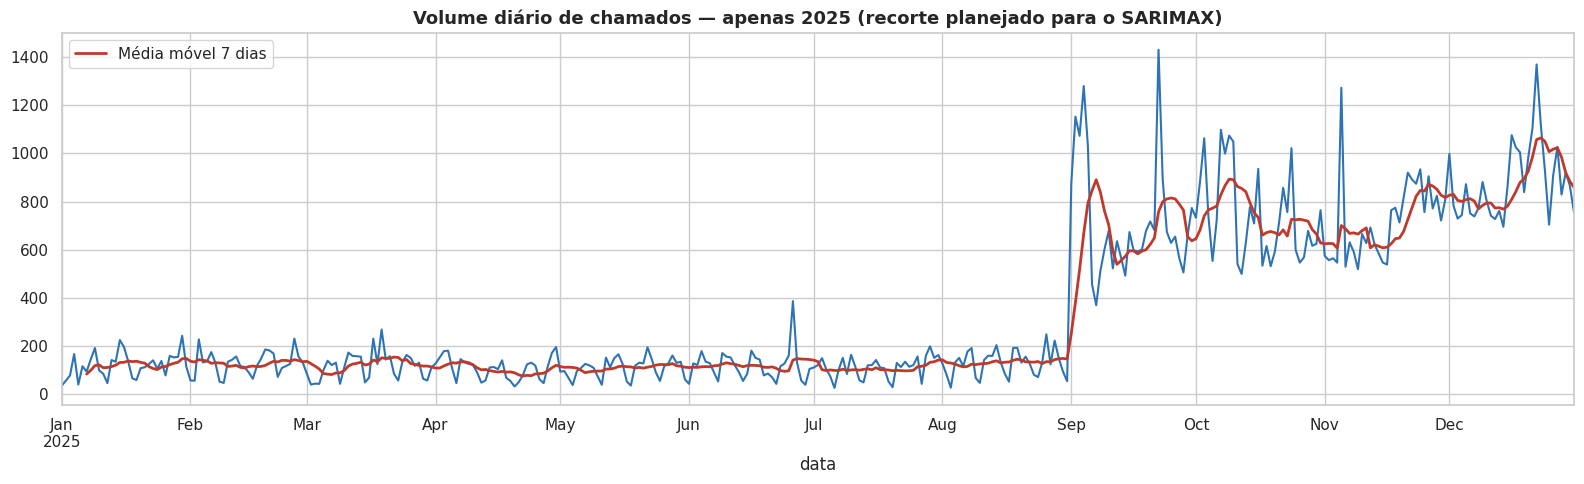

In [ ]:
# Zoom em 2025, para comparação direta com o período que será usado no treino do SARIMAX
volume_2025 = volume_diario[volume_diario.index.year == 2025]
fig, ax = plt.subplots(figsize=(16, 5))
volume_2025.plot(ax=ax, color='#2E74B5')
volume_2025.rolling(7).mean().plot(ax=ax, color='#c0392b', linewidth=2, label='Média móvel 7 dias')
ax.set_title('Volume diário de chamados — apenas 2025 (recorte planejado para o SARIMAX)')
ax.legend()
plt.tight_layout()
plt.show()

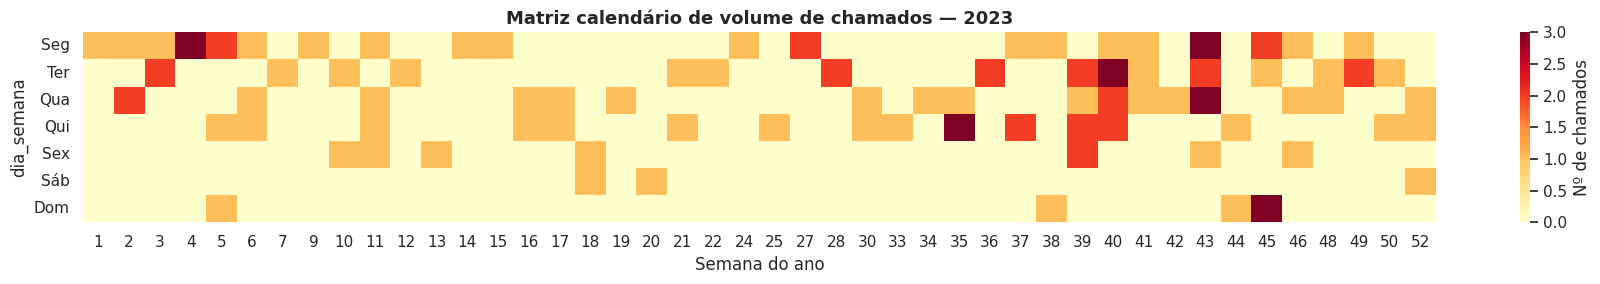

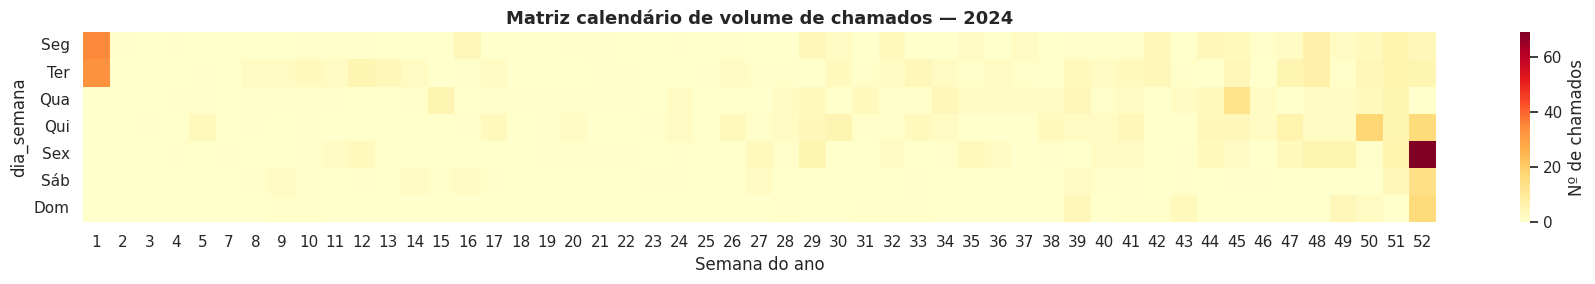

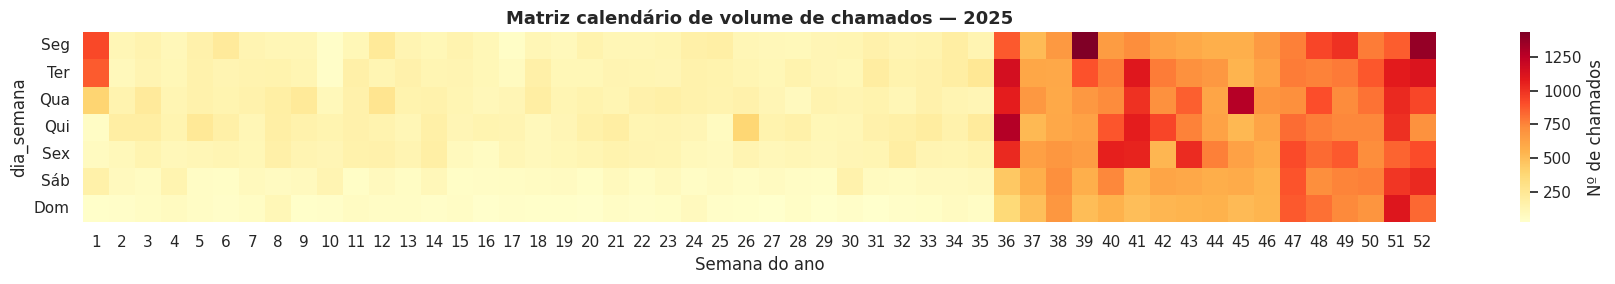

In [ ]:
# Heatmap de calendário: visualiza densidade de chamados por dia, ano a ano
def heatmap_calendario(serie_diaria, ano):
    dados_ano = serie_diaria[serie_diaria.index.year == ano]
    df_cal = dados_ano.to_frame('contagem')
    df_cal['semana'] = df_cal.index.isocalendar().week
    df_cal['dia_semana'] = df_cal.index.dayofweek
    pivot = df_cal.pivot_table(index='dia_semana', columns='semana', values='contagem', fill_value=0)

    fig, ax = plt.subplots(figsize=(18, 3))
    sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Nº de chamados'})
    ax.set_yticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'], rotation=0)
    ax.set_title(f'Matriz calendário de volume de chamados — {ano}')
    ax.set_xlabel('Semana do ano')
    plt.tight_layout()
    plt.show()

for ano in [2023, 2024, 2025]:
    heatmap_calendario(volume_diario, ano)

In [ ]:
# Quantificação direta da mudança de regime (fundamenta a decisão de treinar o SARIMAX só com 2025)
dias_zerados_2023_24 = pd.date_range(volume_diario.index.min(), '2024-12-31').difference(volume_diario.index)
volume_por_ano = df.groupby(df['Aberto'].dt.year).size()
print('Volume total de chamados por ano:')
print(volume_por_ano)
print()
print(f'Dias sem NENHUM chamado entre {volume_diario.index.min().date()} e 2024-12-31: {len(dias_zerados_2023_24)}')

Volume total de chamados por ano:
Aberto
2023       110
2024       622
2025    121811
dtype: int64

Dias sem NENHUM chamado entre 2023-01-02 e 2024-12-31: 451


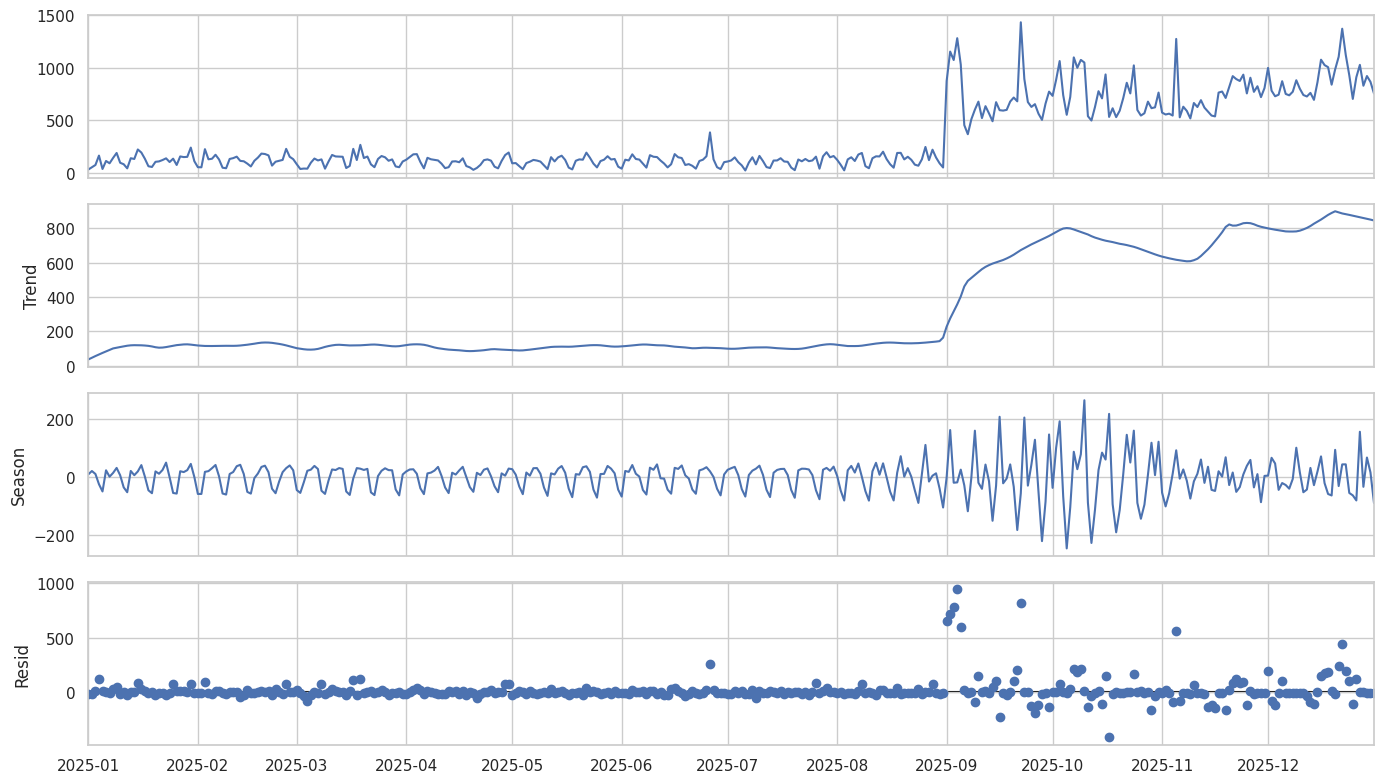

In [ ]:
# Decomposição STL (tendência / sazonalidade / resíduo) sobre 2025
from statsmodels.tsa.seasonal import STL

serie_2025 = volume_2025.asfreq('D').fillna(0)
stl = STL(serie_2025, period=7, robust=True)
resultado_stl = stl.fit()

fig = resultado_stl.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

In [ ]:
# Testes de estacionariedade sobre a série de 2025
from statsmodels.tsa.stattools import adfuller, kpss

adf_stat, adf_p, *_ = adfuller(serie_2025)
print(f'ADF: estatística={adf_stat:.3f}, p-valor={adf_p:.4f}')
print('  -> série estacionária (rejeita H0)' if adf_p < 0.05 else '  -> NÃO estacionária pelo ADF')

kpss_stat, kpss_p, *_ = kpss(serie_2025, regression='c', nlags='auto')
print(f'KPSS: estatística={kpss_stat:.3f}, p-valor={kpss_p:.4f}')
print('  -> série estacionária (não rejeita H0)' if kpss_p > 0.05 else '  -> NÃO estacionária pelo KPSS')

ADF: estatística=0.218, p-valor=0.9733
  -> NÃO estacionária pelo ADF
KPSS: estatística=2.371, p-valor=0.0100
  -> NÃO estacionária pelo KPSS


/tmp/ipykernel_1488/3784403658.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie_2025, regression='c', nlags='auto')


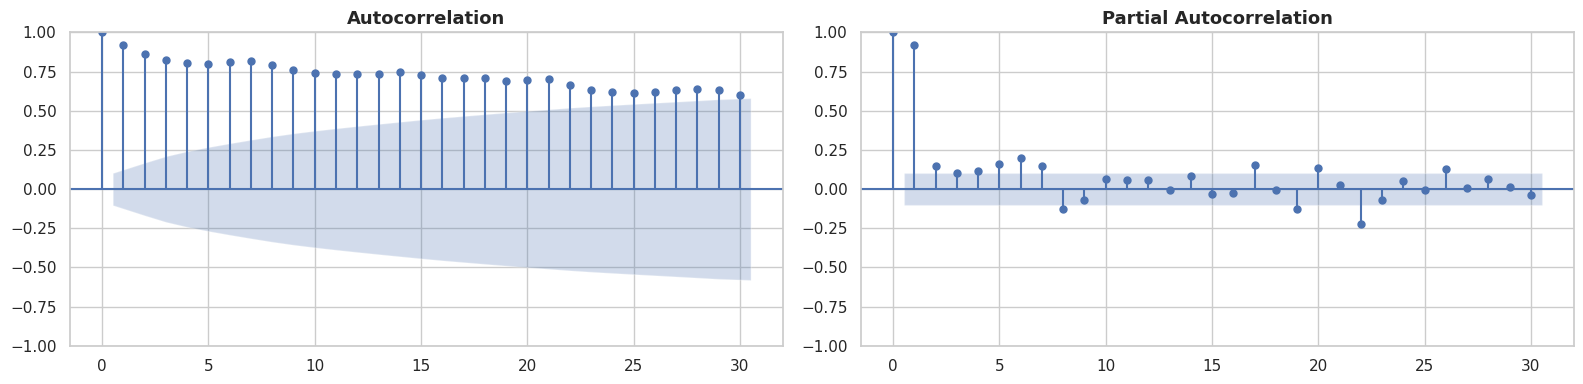

In [ ]:
# ACF e PACF — para checar visualmente a ordem plausível de p, q antes do Auto-ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(serie_2025, lags=30, ax=axes[0])
plot_pacf(serie_2025, lags=30, ax=axes[1])
plt.tight_layout()
plt.show()

## 7. Análise bivariada e cruzamentos-chave

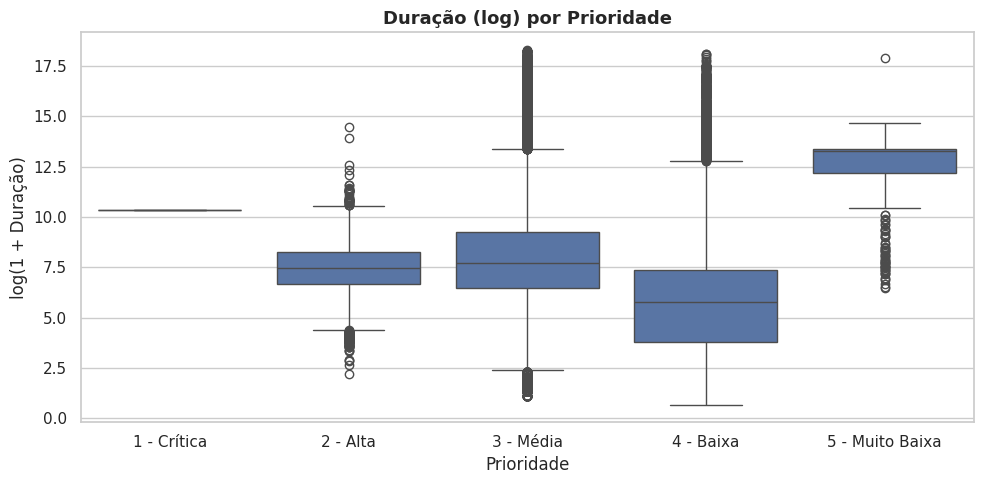

,Duração
Prioridade,
5 - Muito Baixa,575590.0
1 - Crítica,31742.0
3 - Média,2310.0
2 - Alta,1799.0
4 - Baixa,330.0


In [ ]:
# Duração por Prioridade — cuidado com outliers (usar mediana, não média, para leitura robusta)
fig, ax = plt.subplots(figsize=(10, 5))
ordem_prioridade = ['1 - Crítica', '2 - Alta', '3 - Média', '4 - Baixa', '5 - Muito Baixa']
sns.boxplot(data=df, x='Prioridade', y=np.log1p(df['Duração'].clip(lower=0)),
            order=[p for p in ordem_prioridade if p in df['Prioridade'].unique()], ax=ax)
ax.set_ylabel('log(1 + Duração)')
ax.set_title('Duração (log) por Prioridade')
plt.tight_layout()
plt.show()

display(df.groupby('Prioridade')['Duração'].median().sort_values(ascending=False))

In [ ]:
# Status x Prioridade
pd.crosstab(df['Prioridade'], df['Status'], normalize='index').round(3) * 100

Status,Aguardando Problema,Encerrado,Encerrado Automaticamente,Sem Intervenção
Prioridade,,,,
1 - Crítica,0.0,100.0,0.0,0.0
2 - Alta,0.0,59.7,0.3,40.0
3 - Média,0.0,13.5,43.5,43.1
4 - Baixa,0.0,0.5,12.9,86.6
5 - Muito Baixa,0.0,12.9,86.8,0.3


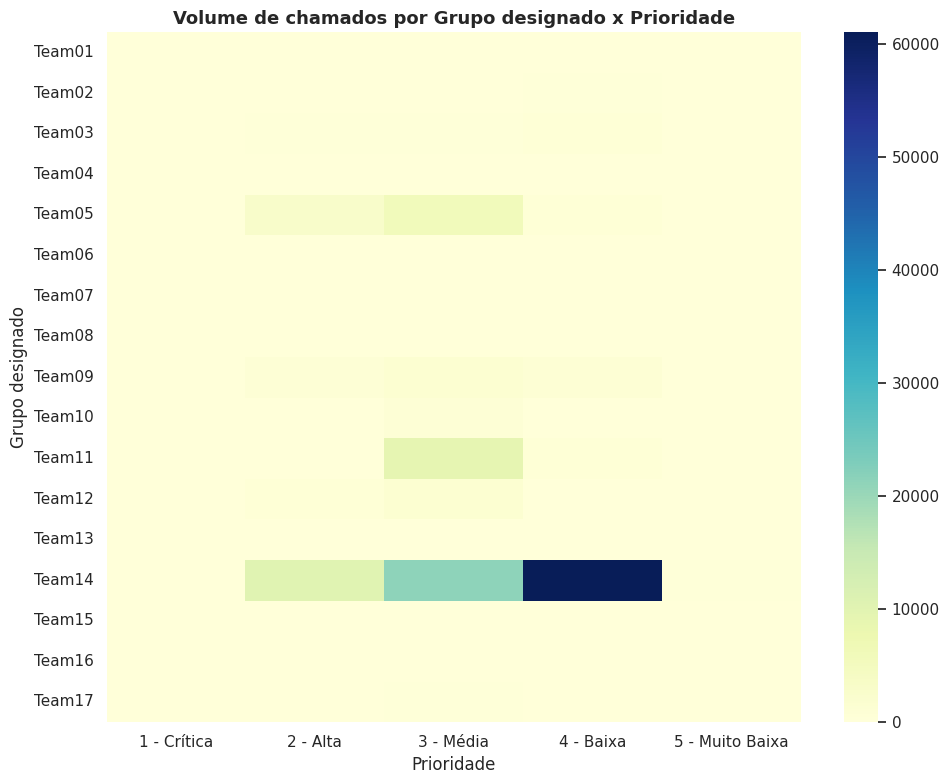

In [ ]:
# Grupo designado x Prioridade (heatmap de concentração)
tabela_grupo_prioridade = pd.crosstab(df['Grupo designado'], df['Prioridade'])
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(tabela_grupo_prioridade, cmap='YlGnBu', annot=False, ax=ax)
ax.set_title('Volume de chamados por Grupo designado x Prioridade')
plt.tight_layout()
plt.show()

In [ ]:
# Entrou para KPI? — em quais Prioridades isso realmente acontece?
pd.crosstab(df['Prioridade'], df['Entrou para KPI?'], normalize='index').round(3) * 100

Entrou para KPI?,NAO,SIM
Prioridade,,
1 - Crítica,100.0,0.0
2 - Alta,67.0,33.0
3 - Média,51.0,49.0
4 - Baixa,100.0,0.0
5 - Muito Baixa,100.0,0.0


## 8. Análise dedicada da variável-alvo (`KPI Violado?`)

Esta seção isola o universo elegível (`Entrou para KPI? == 'SIM'`) e caracteriza a variável-alvo do Desafio 3 em profundidade — é a base direta para a estratégia de classe rara (PR-AUC, Precision@K, sem SMOTE).

In [ ]:
df_kpi = df[df['Entrou para KPI?'] == 'SIM'].copy()
print(f'Universo elegível para KPI: {len(df_kpi):,} chamados ({len(df_kpi)/len(df)*100:.1f}% da base total)'.replace(',', '.'))
print()
contagem_alvo = df_kpi['KPI Violado?'].value_counts(dropna=False)
print(contagem_alvo)
print()
taxa_violacao = (df_kpi['KPI Violado?'] == 'SIM').mean() * 100
print(f'Taxa de violação: {taxa_violacao:.2f}%')

Universo elegível para KPI: 25.600 chamados (20.9% da base total)

KPI Violado?
NAO    25352
SIM      248
Name: count, dtype: int64

Taxa de violação: 0.97%


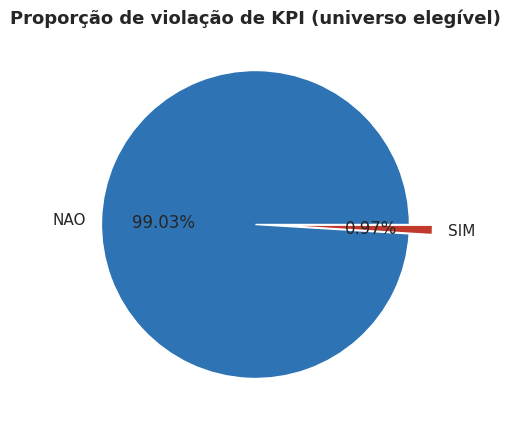

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
contagem_alvo_plot = df_kpi['KPI Violado?'].value_counts()
ax.pie(contagem_alvo_plot, labels=contagem_alvo_plot.index, autopct='%1.2f%%',
       colors=['#2E74B5', '#c0392b'], explode=[0, 0.15])
ax.set_title('Proporção de violação de KPI (universo elegível)')
plt.show()

Taxa de violação (%) por Prioridade:


,KPI Violado?
Prioridade,
3 - Média,1.007778
2 - Alta,0.814111


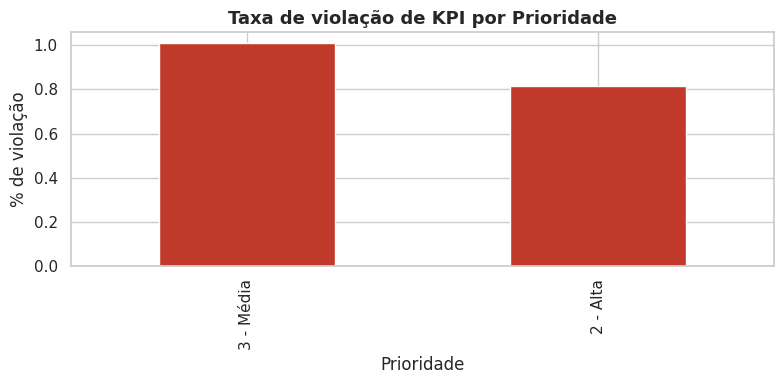

In [ ]:
# Taxa de violação por Prioridade (dentro do universo elegível)
taxa_por_prioridade = df_kpi.groupby('Prioridade')['KPI Violado?'].apply(lambda s: (s == 'SIM').mean() * 100)
taxa_por_prioridade = taxa_por_prioridade.sort_values(ascending=False)
print('Taxa de violação (%) por Prioridade:')
display(taxa_por_prioridade)

fig, ax = plt.subplots(figsize=(8, 4))
taxa_por_prioridade.plot(kind='bar', ax=ax, color='#c0392b')
ax.set_ylabel('% de violação')
ax.set_title('Taxa de violação de KPI por Prioridade')
plt.tight_layout()
plt.show()

In [ ]:
# Taxa de violação por Grupo designado — top 10 grupos com maior volume elegível
top_grupos = df_kpi['Grupo designado'].value_counts().head(10).index
subset_top_grupos = df_kpi[df_kpi['Grupo designado'].isin(top_grupos)]
taxa_por_grupo = subset_top_grupos.groupby('Grupo designado')['KPI Violado?'].apply(lambda s: (s == 'SIM').mean() * 100)
taxa_por_grupo.sort_values(ascending=False)

,KPI Violado?
Grupo designado,
Team07,8.938547
Team03,2.891566
Team09,2.721088
Team12,2.025316
Team02,1.593625
Team11,1.310044
Team17,0.826446
Team10,0.628931
Team05,0.358324


In [ ]:
# Taxa de violação: dia útil vs. fim de semana
df_kpi['fim_de_semana'] = df_kpi['Aberto'].dt.dayofweek >= 5
taxa_fds = df_kpi.groupby('fim_de_semana')['KPI Violado?'].apply(lambda s: (s == 'SIM').mean() * 100)
taxa_fds.index = ['Dia útil', 'Fim de semana']
print('Taxa de violação de KPI:')
display(taxa_fds)
print(f'\nRazão fim de semana / dia útil: {taxa_fds["Fim de semana"] / taxa_fds["Dia útil"]:.2f}x')

Taxa de violação de KPI:


,KPI Violado?
Dia útil,0.868024
Fim de semana,1.585095



Razão fim de semana / dia útil: 1.83x


In [ ]:
# Volume de positivos por semana — dimensiona quantos casos cada fold do walk-forward terá disponível
df_kpi['ano_semana'] = df_kpi['Aberto'].dt.strftime('%Y-W%U')
positivos_por_semana = df_kpi[df_kpi['KPI Violado?'] == 'SIM'].groupby('ano_semana').size()
print(f'Semanas com pelo menos 1 violação: {(positivos_por_semana > 0).sum()}')
print(f'Mediana de violações por semana (entre semanas com >0): {positivos_por_semana[positivos_por_semana > 0].median()}')
positivos_por_semana.tail(20)

Semanas com pelo menos 1 violação: 59
Mediana de violações por semana (entre semanas com >0): 4.0


,0
ano_semana,
2025-W32,3
2025-W33,4
2025-W34,5
2025-W35,2
2025-W36,2
2025-W37,3
2025-W38,4
2025-W40,1
2025-W41,2


## 9. Correlação e associação entre variáveis

A maioria das variáveis deste dataset é categórica — correlação de Pearson não se aplica diretamente. Usamos **Cramér's V** (baseado em qui-quadrado, varia de 0 a 1) para medir força de associação entre pares de categóricas, e correlação de Pearson apenas para as variáveis efetivamente numéricas/temporais derivadas.

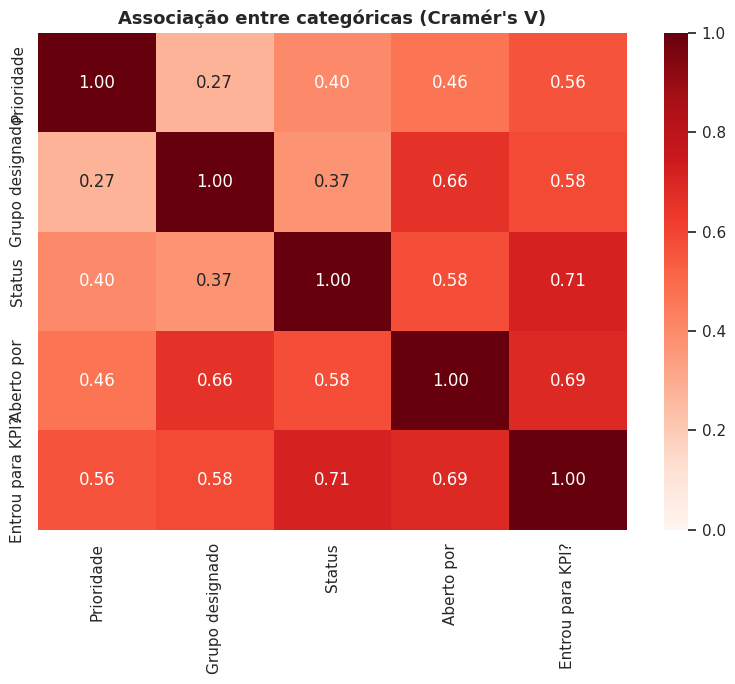

In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

colunas_associacao = ['Prioridade', 'Grupo designado', 'Status', 'Aberto por', 'Entrou para KPI?']
matriz_cramers_v = pd.DataFrame(index=colunas_associacao, columns=colunas_associacao, dtype=float)

for c1 in colunas_associacao:
    for c2 in colunas_associacao:
        matriz_cramers_v.loc[c1, c2] = 1.0 if c1 == c2 else cramers_v(df[c1], df[c2])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(matriz_cramers_v.astype(float), annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1, ax=ax)
ax.set_title("Associação entre categóricas (Cramér's V)")
plt.tight_layout()
plt.show()

In [ ]:
# Dentro do universo elegível para KPI, qual variável mais se associa com KPI Violado??
colunas_vs_alvo = ['Prioridade', 'Grupo designado', 'Aberto por', 'Status']
associacao_com_alvo = {col: cramers_v(df_kpi[col], df_kpi['KPI Violado?']) for col in colunas_vs_alvo}
pd.Series(associacao_com_alvo).sort_values(ascending=False).rename("Cramér's V com KPI Violado?")

,Cramér's V com KPI Violado?
Grupo designado,0.113916
Aberto por,0.038113
Prioridade,0.004026
Status,0.000000


**Nota deliberada:** **Como ler o Cramér's V:** valores próximos de 0 indicam associação fraca/inexistente; acima de ~0,3 já é uma associação relevante para uma variável categórica de negócio. Nenhuma associação individual muito forte com `KPI Violado?` é esperada, dado que a taxa de violação é de ~1% — é exatamente por isso que o modelo do Desafio 3 (CatBoost) precisa combinar várias features fracas simultaneamente, em vez de depender de uma única variável explicativa.